dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module']) Attributes of the dataset
   mean radius  mean texture  ...  worst fractal dimension  target
0        17.99         10.38  ...                  0.11890       0
1        20.57         17.77  ...                  0.08902       0
2        19.69         21.25  ...                  0.08758       0
3        11.42         20.38  ...                  0.17300       0
4        20.29         14.34  ...                  0.07678       0

[5 rows x 31 columns] First 5 rows of the dataset
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothn

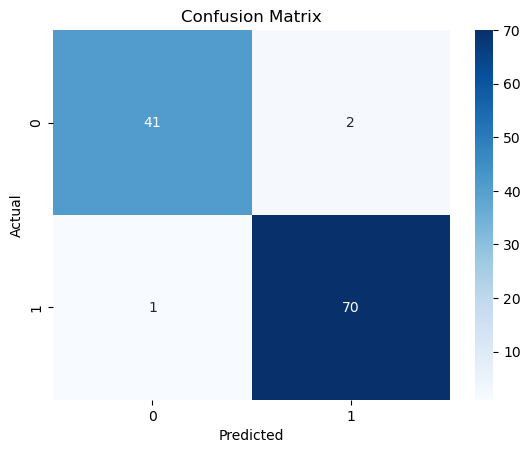

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', RandomForestClassifier(random_state=42))]) Pipeline with Random Forest Classifier
Random Forest Accuracy: 0.96


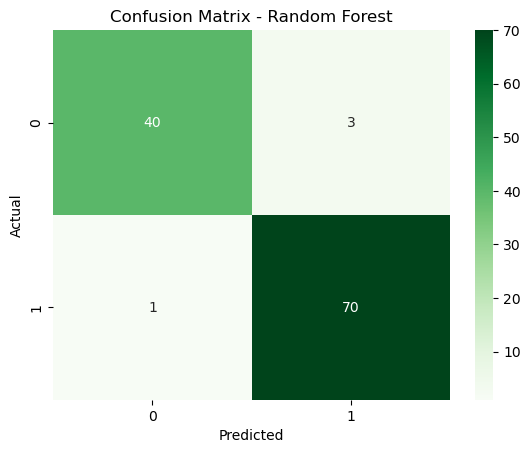

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', SVC(kernel='linear', random_state=42))]) Pipeline with SVM Classifier


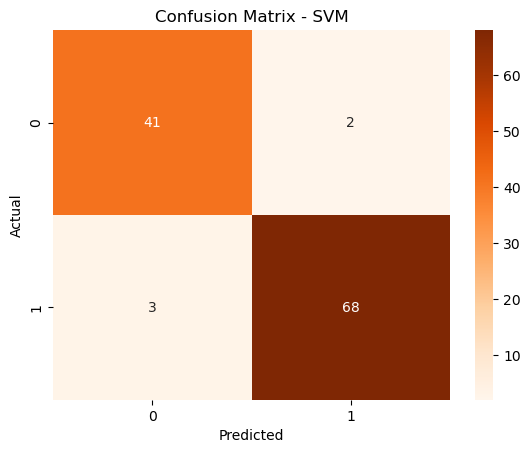

Logistic Regression Accuracy: 0.97
Random Forest Accuracy: 0.96
SVM Accuracy: 0.96


In [14]:
#import necessary libraries
import sklearn.datasets
import sklearn.linear_model
import sklearn.metrics
import sklearn.model_selection
import sklearn.pipeline
import sklearn.preprocessing
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Load the breast cancer dataset
data = sklearn.datasets.load_breast_cancer()
print(data.keys(),"Attributes of the dataset")

# Create a DataFrame for easier analysis
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
print(df.head(),"First 5 rows of the dataset")

# Check for missing values
print(df.isnull().sum(),"Missing values in each column")

# Split the data into features and target
X = df.drop('target', axis=1)
y = df['target']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

# Create a pipeline with a scaler and logistic regression
pipeline = sklearn.pipeline.Pipeline([
    ('scaler', sklearn.preprocessing.StandardScaler()),
    ('classifier', sklearn.linear_model.LogisticRegression())
])

# Train the model
pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_pred = pipeline.predict(X_test)

# Evaluate the model
accuracy = sklearn.metrics.accuracy_score(y_test, y_pred)


# Confusion matrix for logistic regression
conf_matrix = sklearn.metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

#compare the accuracy by using a different model (e.g., Random Forest)
from sklearn.ensemble import RandomForestClassifier

# Create a pipeline with a scaler and random forest classifier
pipeline_rf = sklearn.pipeline.Pipeline([
    ('scaler', sklearn.preprocessing.StandardScaler()),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])
print(pipeline_rf,"Pipeline with Random Forest Classifier")

# Train the random forest model
pipeline_rf.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = pipeline_rf.predict(X_test)

# Evaluate the random forest model
accuracy_rf = sklearn.metrics.accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.2f}")

# Confusion matrix for random forest
conf_matrix_rf = sklearn.metrics.confusion_matrix(y_test, y_pred_rf)
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()  

# find a third model to train the data and compare the results
from sklearn.svm import SVC
# Create a pipeline with a scaler and SVM classifier
pipeline_svm = sklearn.pipeline.Pipeline([
    ('scaler', sklearn.preprocessing.StandardScaler()),
    ('classifier', SVC(kernel='linear', random_state=42))
])
print(pipeline_svm,"Pipeline with SVM Classifier")

# Train the SVM model 
pipeline_svm.fit(X_train, y_train)

# Make predictions on the test set
y_pred_svm = pipeline_svm.predict(X_test)

#create a confusion matrix for SVM
conf_matrix_svm = sklearn.metrics.confusion_matrix(y_test, y_pred_svm)
sns.heatmap(conf_matrix_svm, annot=True, fmt='d', cmap='Oranges')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - SVM')
plt.show()

# Evaluate the SVM model
accuracy_svm = sklearn.metrics.accuracy_score(y_test, y_pred_svm)

#compare the 3 models
print(f"Logistic Regression Accuracy: {accuracy:.2f}")
print(f"Random Forest Accuracy: {accuracy_rf:.2f}")
print(f"SVM Accuracy: {accuracy_svm:.2f}")